## Imports

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Carregamento de dados

In [3]:
df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024(2).csv")

print("\nINFO")
print(df.info())

print("\nDESCRIBE")
print(df.describe())

print("\nVALORES AUSENTES")
print(df.isnull().sum())


INFO
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB
None

DESCRIBE
              Year  Financial L

## EDA

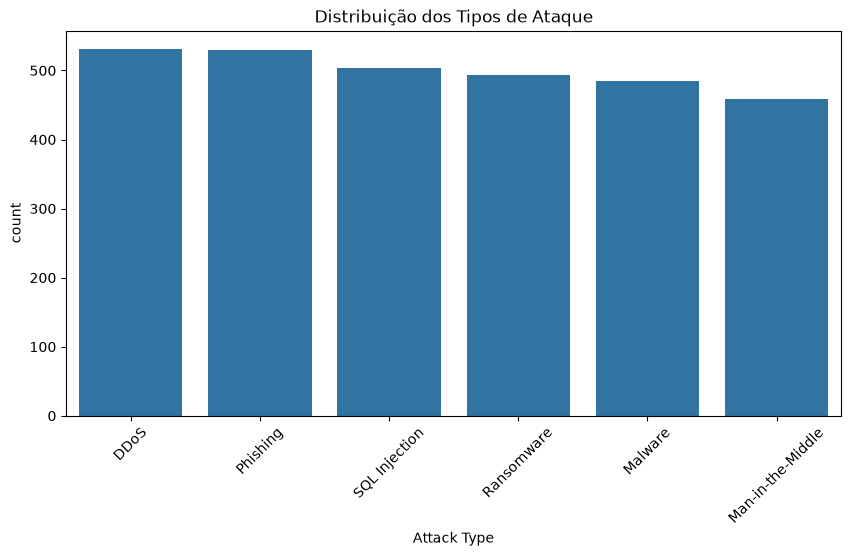

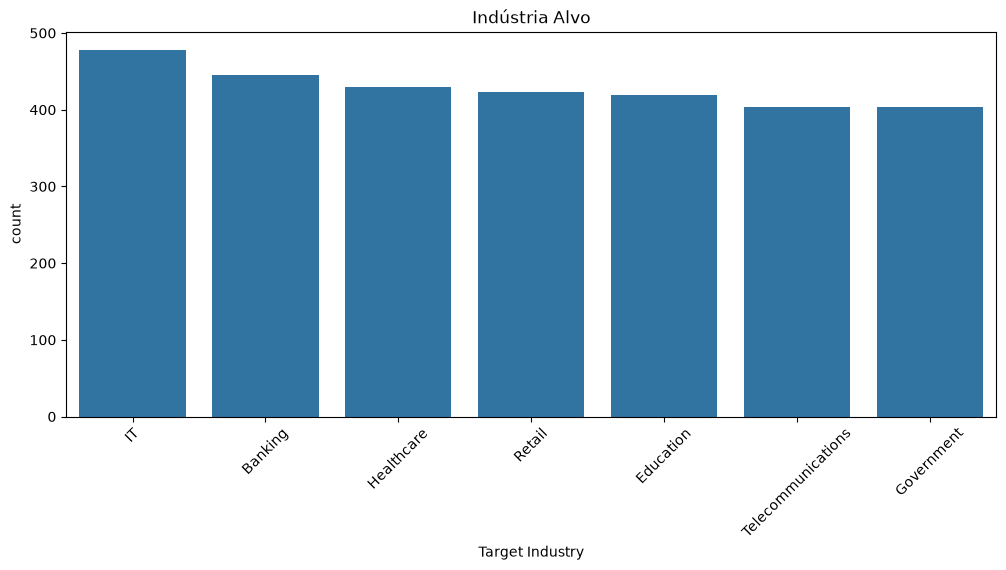

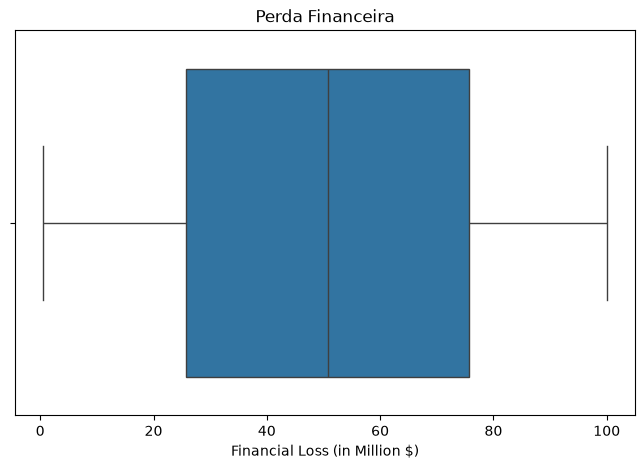

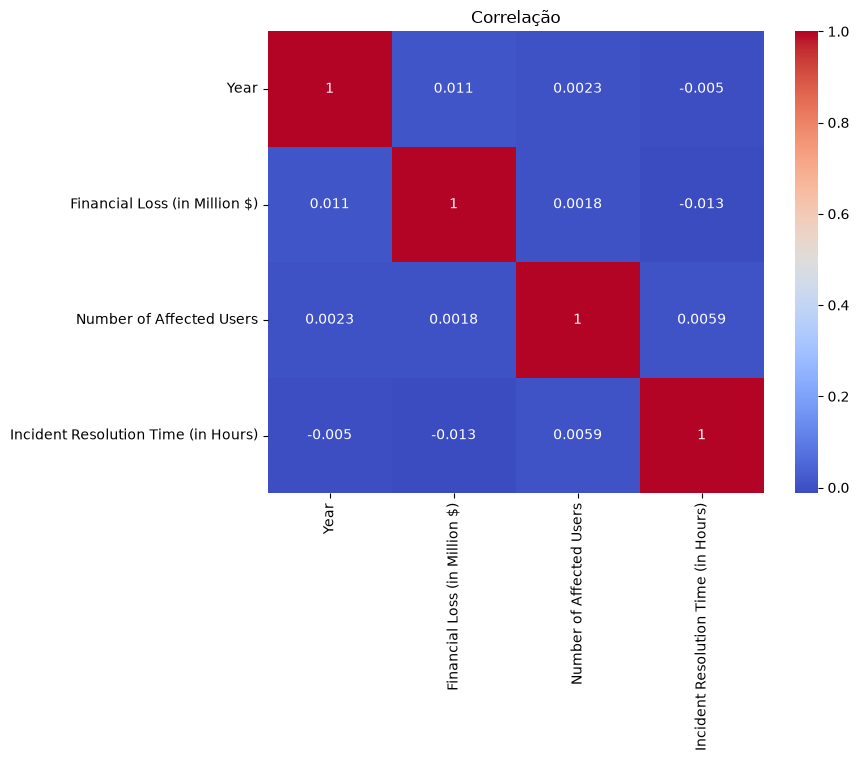

In [4]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Attack Type",
    order=df["Attack Type"].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Distribuição dos Tipos de Ataque")
plt.show()

# Distribuição por indústria
plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x="Target Industry",
    order=df["Target Industry"].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Indústria Alvo")
plt.show()

# Outliers da perda financeira
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Financial Loss (in Million $)"])
plt.title("Perda Financeira")
plt.show()

# Correlação entre variáveis numéricas
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlação")
plt.show()

## Features

In [5]:
features_numericas = [
    "Year",
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]

features_categoricas = [
    "Country",
    "Target Industry",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used"
]

X = df.drop(columns=["Attack Type"])
y = df["Attack Type"]

## Divisão de treino e teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Pré-processamento

In [7]:
transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", transformador_numerico, features_numericas),
    ("cat", transformador_categorico, features_categoricas)
])

## Random forest

In [8]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

param_grid = {
    "classifier__n_estimators":[50,100],
    "classifier__max_depth":[5,10,None],
    "preprocessor__num__imputer__strategy":["mean","median"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

## Predição

In [9]:
y_pred = best_model.predict(X_test)

## Acurácia

In [10]:
print("\nAccuracy:", accuracy_score(y_test,y_pred))


Accuracy: 0.175


## Matriz de confusão

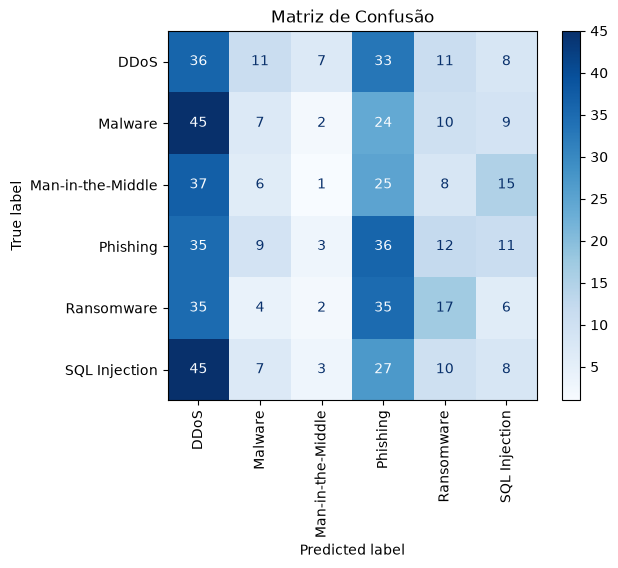

In [11]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Matriz de Confusão")
plt.show()

## Classification report

In [12]:
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test,y_pred))


CLASSIFICATION REPORT
                   precision    recall  f1-score   support

             DDoS       0.15      0.34      0.21       106
          Malware       0.16      0.07      0.10        97
Man-in-the-Middle       0.06      0.01      0.02        92
         Phishing       0.20      0.34      0.25       106
       Ransomware       0.25      0.17      0.20        99
    SQL Injection       0.14      0.08      0.10       100

         accuracy                           0.17       600
        macro avg       0.16      0.17      0.15       600
     weighted avg       0.16      0.17      0.15       600



## Importâncias

                                              Feature  Importance
1                  num__Financial Loss (in Million $)    0.145993
2                       num__Number of Affected Users    0.138105
3            num__Incident Resolution Time (in Hours)    0.108329
0                                           num__Year    0.075102
28          cat__Security Vulnerability Type_Zero-day    0.026626
4                              cat__Country_Australia    0.025776
31             cat__Defense Mechanism Used_Encryption    0.023897
23                    cat__Attack Source_Nation-state    0.023853
19                        cat__Target Industry_Retail    0.022755
32               cat__Defense Mechanism Used_Firewall    0.022386
26  cat__Security Vulnerability Type_Unpatched Sof...    0.021947
25  cat__Security Vulnerability Type_Social Engine...    0.021309
27    cat__Security Vulnerability Type_Weak Passwords    0.020949
20            cat__Target Industry_Telecommunications    0.020349
13        

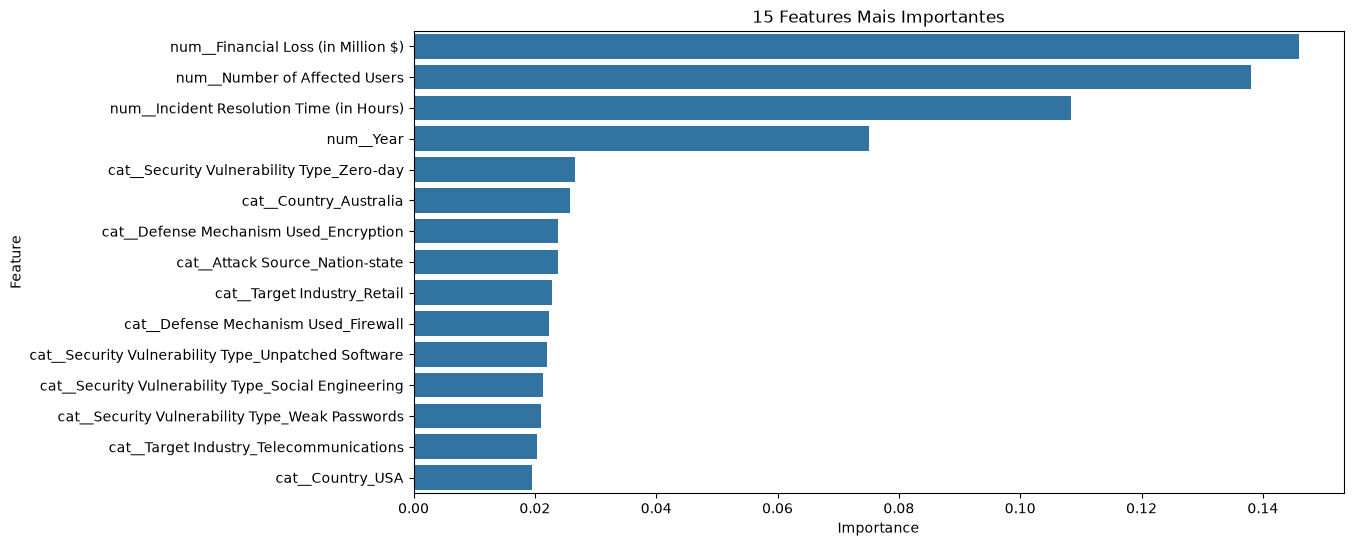

In [13]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = best_model.named_steps[
    "classifier"
].feature_importances_

importancias_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importancias
})

importancias_df = importancias_df.sort_values(
    by="Importance",
    ascending=False
)

print(importancias_df.head(15))

plt.figure(figsize=(12,6))
sns.barplot(
    data=importancias_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("15 Features Mais Importantes")
plt.show()

## Overfitting

In [14]:
train_score = best_model.score(X_train,y_train)
test_score = best_model.score(X_test,y_test)

print("\nAccuracy treino:",train_score)
print("Accuracy teste:",test_score)


Accuracy treino: 0.48541666666666666
Accuracy teste: 0.175


## Grid search

In [15]:
print("\nMelhores parâmetros:")
print(grid.best_params_)

print("\nMelhor acurácia (CV):")
print(grid.best_score_)


Melhores parâmetros:
{'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'mean'}

Melhor acurácia (CV):
0.1775
